In [1]:
!pip install tensorflow

# Importing important libraries:

In [2]:


import numpy as np
import pandas as pd
import pickle as pkl
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPool1D,Embedding,LSTM, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import sequence
import warnings
warnings.filterwarnings('ignore')

# we are going import nlkt
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# loading the Data:

In [3]:

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# view the dataset:

In [4]:

train.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\r\nWhy the edits made under my use...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\r\nMore\r\nI can't make any real suggestions...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\r\n\r\nCongratulations from me as well, use ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [5]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \r\n\r\n The title is fine as i...
2,00013b17ad220c46,""" \r\n\r\n == Sources == \r\n\r\n * Zawe Ashto..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


# Drop the id column in both train and test data:

In [6]:
train = train.drop('id', axis = 1)
test = test.drop('id', axis = 1)

# let's checking how comments are represented:

In [7]:
train['comment_text'][10]

'"\r\nFair use rationale for Image:Wonju.jpg\r\n\r\nThanks for uploading Image:Wonju.jpg. I notice the image page specifies that the image is being used under fair use but there is no explanation or rationale as to why its use in Wikipedia articles constitutes fair use. In addition to the boilerplate fair use template, you must also write out on the image description page a specific explanation or rationale for why using this image in each article is consistent with fair use.\r\n\r\nPlease go to the image description page and edit it to include a fair use rationale.\r\n\r\nIf you have uploaded other fair use media, consider checking that you have specified the fair use rationale on those pages too. You can find a list of \'image\' pages you have edited by clicking on the ""my contributions"" link (it is located at the very top of any Wikipedia page when you are logged in), and then selecting ""Image"" from the dropdown box. Note that any fair use images uploaded after 4 May, 2006, and 

# Getting an idea about data:

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   comment_text   159571 non-null  object
 1   toxic          159571 non-null  int64 
 2   severe_toxic   159571 non-null  int64 
 3   obscene        159571 non-null  int64 
 4   threat         159571 non-null  int64 
 5   insult         159571 non-null  int64 
 6   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 8.5+ MB


In [9]:
"""
As we see here we can can understand like datatypes, non null counts and how many columns like that
There is no null values in out train data
"""

'\nAs we see here we can can understand like datatypes, non null counts and how many columns like that\nThere is no null values in out train data\n'

# Getting an idea about null values:

In [10]:
train.isnull().sum().any()

np.False_

In [11]:
test.isnull().sum().any()

np.False_

In [12]:
'np.False_ means there no null values present in out train data and both test data as well'

'np.False_ means there no null values present in out train data and both test data as well'

# Getting an idea about duplicated values :

In [13]:
train.duplicated().sum()

np.int64(0)

In [14]:
test.duplicated().sum()

np.int64(0)

In [15]:
"np.int64(0) indicates there is no duplicates both train and test data"

'np.int64(0) indicates there is no duplicates both train and test data'

# Checking how target columns are balanced or not:
# checking the uniques for each columns:

In [16]:
train.nunique()

,0
comment_text,159571
toxic,2
severe_toxic,2
obscene,2
threat,2
insult,2
identity_hate,2


In [17]:
'''Here we have comment_text is each every text is unique
    toxic,severe_toxic, obscence, threat, insult, identity_hate
    these are having only two unique like 1 and 0

'''

'Here we have comment_text is each every text is unique\n    toxic,severe_toxic, obscence, threat, insult, identity_hate\n    these are having only two unique like 1 and 0\n\n'

# Heatmap for target variables

In [18]:

corr = train.iloc[:, 1:7].corr()
corr

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,1.000000,0.308619,0.676515,0.157058,0.647518,0.266009
severe_toxic,0.308619,1.000000,0.403014,0.123601,0.375807,0.201600
obscene,0.676515,0.403014,1.000000,0.141179,0.741272,0.286867
threat,0.157058,0.123601,0.141179,1.000000,0.150022,0.115128
insult,0.647518,0.375807,0.741272,0.150022,1.000000,0.337736
identity_hate,0.266009,0.201600,0.286867,0.115128,0.337736,1.000000


Text(0.5, 1.0, 'Correlation Between Training Taget Labels')

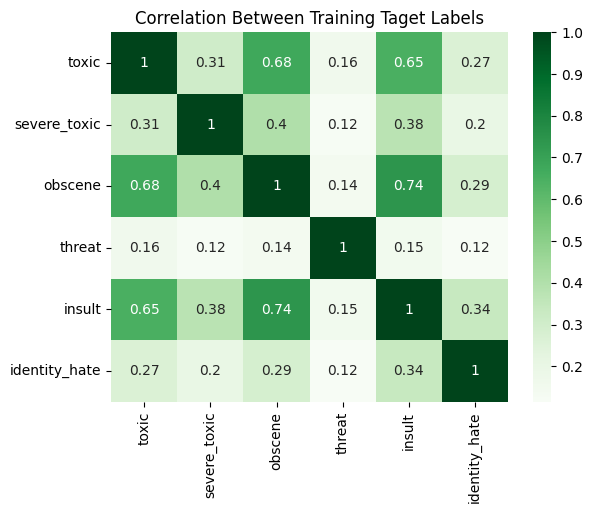

In [19]:
import seaborn as sns
sns.heatmap(corr, annot = True, cmap = 'Greens')
plt.title("Correlation Between Training Taget Labels")

In [20]:

#Here Above 0.7 has strong positive correlation
"""
(toxic and insult), (toxic and obsence) having positive correlation
(insult and obsence), having positive correlation """

# here above 0.1 and within 0.3 considered as weak positive correaltion
"""
identity_hate and (toxic,treat,severe_taxioc) having weak positive correlation.
(severe_taxioc and identity_hate), (severe_taxioc, insult), (severe_taxioc, Threat), having weak positive correaltion
threat column having weak positive corrlation between all the columns
insult and threat having weak positive correlation """

# moderate positive correlation:
"""
obscene and severe_taxioc having moderate correlation
insult and severe_taxioc having moderate positive correlation
identity_rate and insult having moderate positive correlation

"""

'\nobscene and severe_taxioc having moderate correlation\ninsult and severe_taxioc having moderate positive correlation\nidentity_rate and insult having moderate positive correlation\n\n'

# lets us see our taget classes distribution:

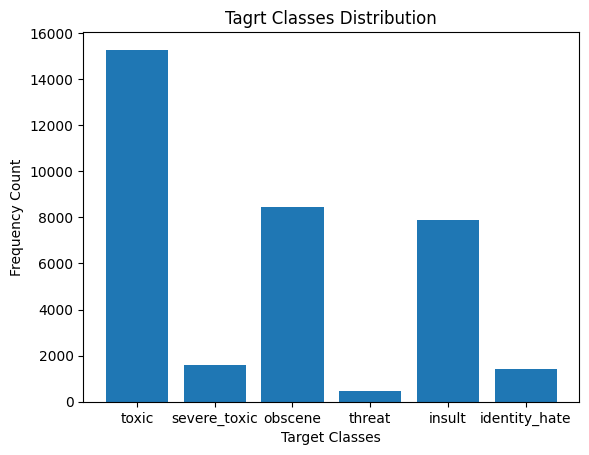

In [21]:

target_classes = train.iloc[:, 1:].sum()
plt.Figure(figsize = (5, 2) )
plt.bar(target_classes.index, target_classes.values)
plt.xlabel("Target Classes")
plt.ylabel("Frequency Count")
plt.title("Tagrt Classes Distribution")
plt.show()

In [22]:
" Here we can see highest count is toxic,obscence, insult. "
"And lowest count is threat, severe_toxic, identity_hate. "

'And lowest count is threat, severe_toxic, identity_hate. '

# Text preprocessing:

In [23]:
# doenload the stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [24]:
# text cleanning :
import re
def comments_cleaning(comment):
    comments = comment.lower()
    comments = re.sub(r'[^a-zA-z]', " ", comment)
    words = comments.split()
    stop_words = stopwords.words('english')
    comments = [word for word in words if word not in stop_words]

    return " ".join(comments)

In [25]:
train['cleaned_comment_text'] = train['comment_text'].apply(comments_cleaning)
train['cleaned_comment_text'] = train['cleaned_comment_text'].str.lower()

In [26]:
test['cleaned_comment_text'] = test['comment_text'].apply(comments_cleaning)
train['cleaned_comment_text'] = train['cleaned_comment_text'].str.lower()


In [27]:
train['cleaned_comment_text'].head()

,cleaned_comment_text
0,explanation why edits made username hardcore m...
1,d aww he matches background colour i seemingly...
2,hey man i really trying edit war it guy consta...
3,more i make real suggestions improvement i won...
4,you sir hero any chance remember page


In [28]:
test['cleaned_comment_text'].head()

,cleaned_comment_text
0,Yo bitch Ja Rule succesful ever whats hating s...
1,From RfC The title fine IMO
2,Sources Zawe Ashton Lapland
3,If look back source information I updated corr...
4,I anonymously edit articles


In [29]:
# tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train['cleaned_comment_text'])

In [30]:
# count words:
word_index = tokenizer.word_index
vocab_size = len(word_index)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 168814


In [31]:
from keras.preprocessing import sequence
# padding the text data -> we have convert hole text in to uniform features:
sequences = tokenizer.texts_to_sequences(train['cleaned_comment_text'])
#sequences

In [32]:
max(len(data) for data in train['cleaned_comment_text'])

5000

In [33]:
min(len(data) for data in train['cleaned_comment_text'])

0

In [34]:
max_sequence_length = 200

In [35]:
padded_seq = pad_sequences(sequences, maxlen = max_sequence_length, padding = 'post', truncating = 'post')

In [36]:
padded_seq[2000]

array([291, 150, 291,  35, 268,  19,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

# Create embedding index:

In [37]:
# create embedding index:
embedding_index = {}
with open('/content/glove.6B.200d.txt', encoding = 'utf-8') as f:
  for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype = 'float32')
    embedding_index[word] = coefs

In [38]:
# lets display embedding the coressponding the word:
embedding_index['good']

array([ 5.1507e-01,  3.5596e-01,  1.5710e-01, -7.4075e-02, -2.5446e-01,
       -1.1357e-01, -4.9943e-01, -1.2626e-01,  3.8851e-01,  5.4204e-01,
        1.0479e-01,  4.4099e-01, -6.5490e-02,  5.8463e-02,  4.1150e-01,
        5.6709e-01, -1.1869e-01,  2.5107e-01,  2.5640e-01, -2.1615e-01,
        6.4170e-01,  2.7875e+00,  1.2036e-01,  4.9481e-02,  2.4843e-01,
       -6.7390e-01,  1.1957e-03,  3.5802e-01, -1.7588e-01, -3.9135e-01,
       -1.4093e-02,  2.3610e-01, -4.3184e-01, -2.7045e-02,  2.2829e-02,
       -2.8283e-01, -5.0008e-01, -1.1275e-01, -4.5002e-01,  3.3634e-01,
       -5.7722e-03,  3.3005e-01, -2.4671e-01,  1.7358e-01, -3.5508e-01,
       -3.9378e-02,  4.8834e-01,  1.4180e-01, -1.7579e-01,  3.1760e-01,
       -1.5194e-01, -1.1244e-01, -7.0078e-02,  7.4877e-01, -6.2074e-02,
       -1.7296e-01,  1.5001e-01, -5.8035e-02,  1.9471e-01, -2.9521e-01,
        5.0281e-01, -3.3074e-01, -5.4041e-01,  6.4659e-02,  4.1465e-02,
        4.9930e-01,  8.0902e-02,  4.7806e-01,  5.8307e-01,  4.08

In [39]:
len(embedding_index['good'])

200

In [40]:
'it will just give similar representations 100 vectors coressponding word'

'it will just give similar representations 100 vectors coressponding word'

In [41]:
# create embedding matrix :
embedding_dim = 200
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
for word, i in word_index.items():
  embedding_vector = embedding_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector

In [42]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.26804999,  0.36032   , -0.33199999, ...,  0.17769   ,
         0.22362   ,  0.014241  ],
       [-0.68656999,  0.95512998,  0.36618   , ...,  0.26440001,
         0.29328999, -0.15655001],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.30359   ,  0.40026   , -0.79053998, ..., -0.071854  ,
         0.19005001,  0.77008998],
       [-0.35091999, -0.39853999, -0.13873   , ...,  0.17846   ,
         0.10405   ,  0.055404  ]])

In [43]:

y = train.iloc[:, 1:7].values

print(f"Shape of padded_seq: {padded_seq.shape}")
print(f"Shape of y: {y.shape}")

Shape of padded_seq: (159571, 200)
Shape of y: (159571, 6)


In [44]:
# input pipeline
indices = np.arange(padded_seq.shape[0])
np.random.shuffle(indices)
padded_seq = padded_seq[indices]
y = y[indices]

In [45]:
validation_split = 0.2
num_validation_samples = int(validation_split*padded_seq.shape[0])


In [46]:
num_validation_samples

31914

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(padded_seq, y, test_size=0.1, random_state=42)
#X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_train = X_train[:-num_validation_samples]
y_train = y_train[:-num_validation_samples]
X_val = X_train[-num_validation_samples:]
y_val =y_train[-num_validation_samples:]


In [48]:
# display the length od each catgory :
print("X_Training data_length :", len(X_train))
print("y_Training data_length :", len(y_train))
print("X_val data_length :", len(X_val))
print("y_Training data_length :", len(y_val))
print("X_test data_length :", len(X_test))
print("y_test data_length :", len(y_test))

X_Training data_length : 111699
y_Training data_length : 111699
X_val data_length : 31914
y_Training data_length : 31914
X_test data_length : 15958
y_test data_length : 15958


# Model Building for LSTM:

In [49]:
from tensorflow.keras.layers import Bidirectional, LSTM
max_sequence_length = 200
model = Sequential()
# Create the embedding layer
model.add(Embedding(vocab_size + 1, embedding_dim, weights=[embedding_matrix], input_length=max_sequence_length, trainable=False, name = 'embedding_layer'))
# Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(32, activation='tanh')))
# Feature extractor Fully connected layers
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
# Final layer
model.add(Dense(6, activation='sigmoid'))

In [50]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics = ['accuracy'])

In [51]:
history = model.fit(X_train, y_train, epochs = 2, batch_size = 64, validation_data = (X_val, y_val))

Epoch 1/2
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9840 - loss: 0.0687 - val_accuracy: 0.9942 - val_loss: 0.0520
Epoch 2/2
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9870 - loss: 0.0517 - val_accuracy: 0.9942 - val_loss: 0.0455


In [52]:
'model is not overfitted'

'model is not overfitted'

# Getting model summary()

In [53]:
# Getting model summary():
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 200, 200)       │    33,763,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        59,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,116,492 (130.14 MB)

 Trainable params: 117,830 (460.27 KB)

 Non-trainable params: 33,763,000 (128.80 MB)

 Optimizer params: 235,662 (920.56 KB)

# plotting the loss and accuracy :

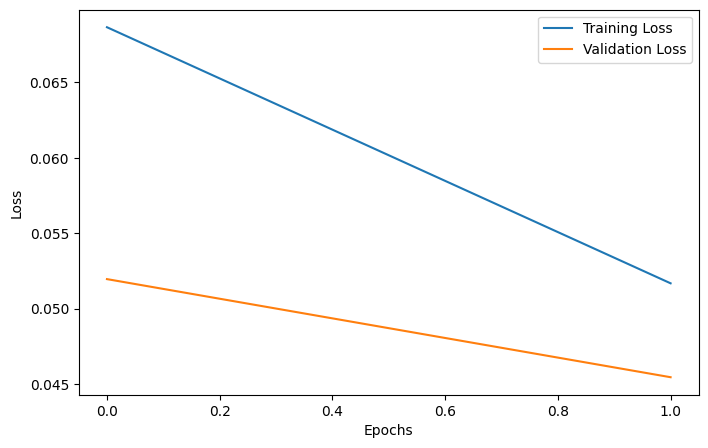

In [54]:
# plotting the loss :
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

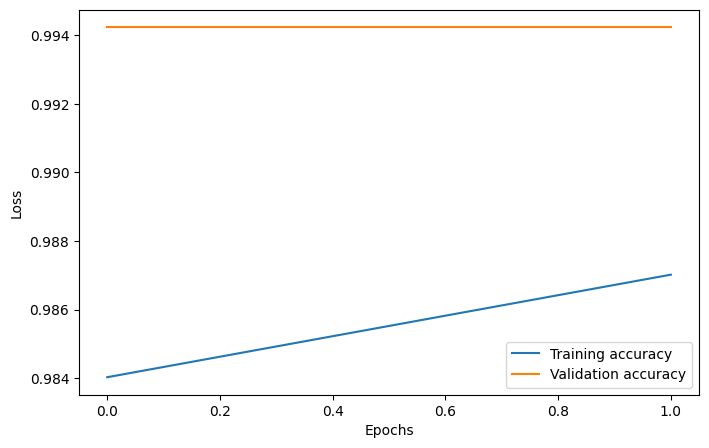

In [55]:
# plotting the accuracy :
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# save the model:

In [56]:
# save the model:

with open('model_lstm.pkl', 'wb') as f:
  pkl.dump(model, f)

# loading the model:

In [57]:
# loading the model:
with open('model_lstm.pkl', 'rb') as f:
  model = pkl.load(f)
print(model)

<Sequential name=sequential, built=True>


In [58]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 200, 200)       │    33,763,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        59,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,116,492 (130.14 MB)

 Trainable params: 117,830 (460.27 KB)

 Non-trainable params: 33,763,000 (128.80 MB)

 Optimizer params: 235,662 (920.56 KB)

In [59]:
sequences_test = tokenizer.texts_to_sequences(test['cleaned_comment_text'])

In [60]:
padded_seq_test = pad_sequences(sequences_test, maxlen = max_sequence_length, padding = 'post', truncating = 'post')

In [61]:
# prediction :
predictions = model.predict(padded_seq_test)

4787/4787 ━━━━━━━━━━━━━━━━━━━━ 32s 7ms/step


In [62]:
predictions[0]

array([0.99822026, 0.24532771, 0.9762097 , 0.01924593, 0.88212126,
       0.14880246], dtype=float32)

In [63]:
text = "COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK"
max_len = 200
text = comments_cleaning(text)
text = tokenizer.texts_to_sequences([text])
text = pad_sequences(text, maxlen = max_len, padding = 'post', truncating = 'post')
predictions_ = model.predict(text)
predictions_


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


array([[0.81065744, 0.01312815, 0.50205576, 0.01069236, 0.25717783,
        0.00720441]], dtype=float32)

In [64]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
predictions_ = np.where(predictions_ > 0.5, 1, 0)
df = pd.DataFrame(predictions_, columns=labels)
df.head(1)

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,1,0,1,0,0,0


In [65]:
predictions

array([[9.98220265e-01, 2.45327711e-01, 9.76209700e-01, 1.92459263e-02,
        8.82121265e-01, 1.48802459e-01],
       [7.92317151e-04, 7.39175903e-07, 1.41744531e-04, 7.29477761e-05,
        7.69142789e-05, 6.81900519e-06],
       [5.68297924e-04, 7.34662706e-07, 1.08176675e-04, 5.33343446e-05,
        5.26467011e-05, 4.02391561e-06],
       ...,
       [2.55032228e-05, 2.24346763e-09, 1.94767290e-06, 2.27407577e-06,
        8.88596730e-07, 7.29451841e-08],
       [8.41696310e-05, 2.68864735e-08, 1.01184723e-05, 1.02898666e-05,
        4.68932649e-06, 7.13311408e-07],
       [9.64200735e-01, 1.80075131e-02, 8.36326718e-01, 4.64010099e-03,
        3.72130930e-01, 4.19379957e-03]], dtype=float32)

In [66]:
y_predictions = (predictions > 0.5).astype(int)

In [67]:
y_predictions

array([[1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0]])

In [68]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
predictions = np.where(predictions > 0.5, 1, 0)
df_bulk = pd.DataFrame(predictions, columns=labels)
df_bulk.head(100)

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,1,0,1,0,1,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
95,0,0,0,0,0,0
96,0,0,0,0,0,0
97,0,0,0,0,0,0
98,0,0,0,0,0,0


In [69]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [70]:
y_pred

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')

# For detailed report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.70      0.76      1492
           1       0.58      0.04      0.08       166
           2       0.86      0.76      0.81       834
           3       0.00      0.00      0.00        51
           4       0.83      0.60      0.69       783
           5       0.71      0.33      0.45       136

   micro avg       0.83      0.64      0.72      3462
   macro avg       0.64      0.41      0.47      3462
weighted avg       0.81      0.64      0.70      3462
 samples avg       0.06      0.06      0.06      3462



In [72]:
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Precision: 0.8316345790864477
Recall: 0.6363373772385904
F1 Score: 0.7209949271804942


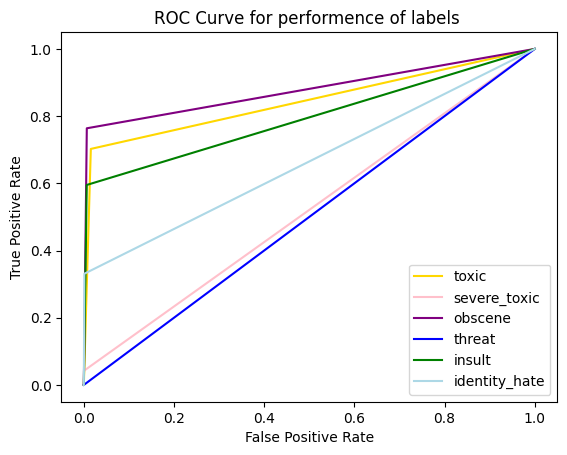

In [73]:
#plot roc curve
from sklearn.metrics import roc_curve, auc

def plot_roc(y, y_pred, colors, labels):

    fpr, tpr, thresholds = roc_curve(y, y_pred)

    plt.plot(fpr, tpr, color=colors, lw = 1.5, label = labels)


    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for performence of labels ')
    plt.legend()


plot_roc(y_test[:, 0], y_pred[:, 0],'gold', 'toxic')
plot_roc(y_test[:, 1], y_pred[:, 1],"pink", 'severe_toxic')
plot_roc(y_test[:, 2], y_pred[:, 2],"purple", 'obscene')
plot_roc(y_test[:, 3], y_pred[:, 3],"blue", 'threat')
plot_roc(y_test[:, 4], y_pred[:, 4],"green", 'insult')
plot_roc(y_test[:, 5], y_pred[:, 5],"lightblue", 'identity_hate')



# Model Building RNNs

In [ ]:
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.regularizers import l2
# Building the model
model2 = Sequential()
model2.add(Embedding(vocab_size + 1, embedding_dim, input_length = max_len))
model2.add(SimpleRNN(100, activation='tanh'))
model2.add(Dense(128, activation = 'relu'))
#model2.add(Dropout(0.3))
model2.add(Dense(256, activation = 'relu', kernel_regularizer=l2(0.001)))
model2.add(Dense(64, activation = 'relu', kernel_regularizer=l2(0.001)))
model2.add(Dense(6, activation = 'sigmoid'))

In [120]:
# Model compilation:
model2.compile(loss='binary_crossentropy', optimizer='Adam', metrics = ['accuracy'])

In [123]:
# Training the model:
history = model2.fit(X_train, y_train, epochs = 10, batch_size = 64, validation_data = (X_val, y_val))

Epoch 1/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step - accuracy: 0.9942 - loss: 0.1362 - val_accuracy: 0.9942 - val_loss: 0.1402
Epoch 2/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.9942 - loss: 0.1414 - val_accuracy: 0.9942 - val_loss: 0.1408
Epoch 3/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9942 - loss: 0.1407 - val_accuracy: 0.9942 - val_loss: 0.1385
Epoch 4/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - accuracy: 0.9942 - loss: 0.1401 - val_accuracy: 0.9942 - val_loss: 0.1388
Epoch 5/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9942 - loss: 0.1398 - val_accuracy: 0.9942 - val_loss: 0.1381
Epoch 6/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 84s 27ms/step - accuracy: 0.9942 - loss: 0.1394 - val_accuracy: 0.9942 - val_loss: 0.1385
Epoch 7/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9942 - loss: 0.1393 - val_accuracy: 0.9942 - val_loss: 0.1381
Epoch 8/10
1746/1746 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9942 -

In [79]:
"our model is not overfitted"

'our model is not overfitted'

In [124]:
# getting model summary:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 200)       │    33,763,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,567,672 (387.45 MB)

 Trainable params: 33,855,890 (129.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,711,782 (258.30 MB)

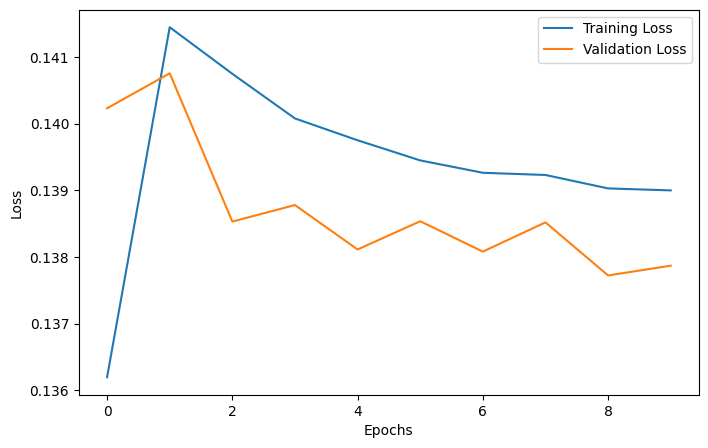

In [125]:
# plotting the loss and accuracy :
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

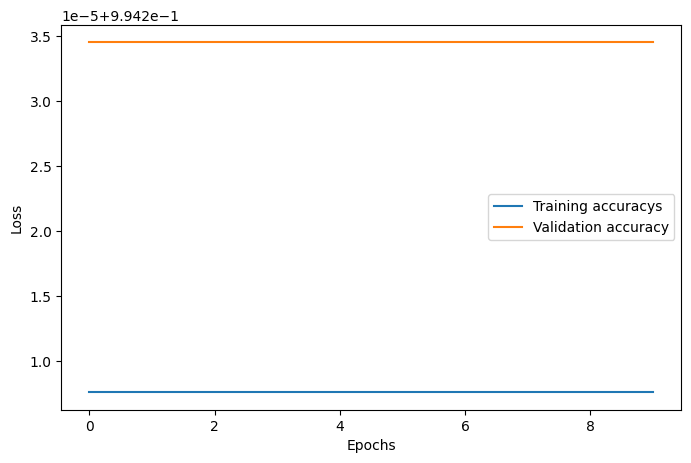

In [126]:
# plotting the accuracy :
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training accuracys')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [127]:
# save the model:
import pickle as pkl
with open('model_RNNs.pkl', 'wb') as f:
  pkl.dump(model2, f)

In [128]:
# loading the model:
import pickle as pkl
with open('model_RNNs.pkl', 'rb') as f:
  model_rnn = pkl.load(f)


In [129]:
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 200)       │    33,763,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,567,672 (387.45 MB)

 Trainable params: 33,855,890 (129.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,711,782 (258.30 MB)

# bulk input prediction:

In [130]:
# prediction:
predictions_rnn = model_rnn.predict(padded_seq_test)

4787/4787 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step


In [131]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
predictions = np.where(predictions_rnn > 0.5, 1, 0)
df_bulk_rnn = pd.DataFrame(predictions, columns=labels)
df_bulk_rnn.head(100)

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
95,0,0,0,0,0,0
96,0,0,0,0,0,0
97,0,0,0,0,0,0
98,0,0,0,0,0,0


# single input prediction

In [132]:
text = "COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK"
max_len = 200
text = comments_cleaning(text)
text = tokenizer.texts_to_sequences([text])
text = pad_sequences(text, maxlen = max_len, padding = 'post', truncating = 'post')
predictions_ = model_rnn.predict(text)
predictions_


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


array([[0.08866385, 0.00892049, 0.04583954, 0.00239581, 0.04421254,
        0.00737794]], dtype=float32)

In [135]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
predictions_ = np.where(predictions_ > 0.5, 1, 0)
df = pd.DataFrame(predictions_, columns=labels)
df.head(1)

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0


In [ ]:
y_pred = model_rnn.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


# metrics

In [137]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')
f1 = f1_score(y_test, y_pred, average='micro')

# For detailed report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.70      0.76      1492
           1       0.58      0.04      0.08       166
           2       0.86      0.76      0.81       834
           3       0.00      0.00      0.00        51
           4       0.83      0.60      0.69       783
           5       0.71      0.33      0.45       136

   micro avg       0.83      0.64      0.72      3462
   macro avg       0.64      0.41      0.47      3462
weighted avg       0.81      0.64      0.70      3462
 samples avg       0.06      0.06      0.06      3462



#plot roc curve

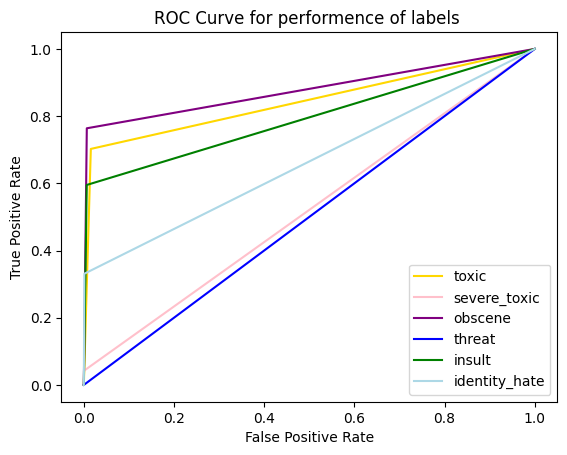

In [138]:
#plot roc curve
from sklearn.metrics import roc_curve, auc

def plot_roc(y, y_pred, colors, labels):

    fpr, tpr, thresholds = roc_curve(y, y_pred)

    plt.plot(fpr, tpr, color=colors, lw = 1.5, label = labels)


    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for performence of labels ')
    plt.legend()


plot_roc(y_test[:, 0], y_pred[:, 0],'gold', 'toxic')
plot_roc(y_test[:, 1], y_pred[:, 1],"pink", 'severe_toxic')
plot_roc(y_test[:, 2], y_pred[:, 2],"purple", 'obscene')
plot_roc(y_test[:, 3], y_pred[:, 3],"blue", 'threat')
plot_roc(y_test[:, 4], y_pred[:, 4],"green", 'insult')
plot_roc(y_test[:, 5], y_pred[:, 5],"lightblue", 'identity_hate')

In [141]:
import pandas as pd
new = pd.DataFrame()

In [142]:
new['cleaned_comment_text'] = train['cleaned_comment_text']
new.head()

,cleaned_comment_text
0,explanation why edits made username hardcore m...
1,d aww he matches background colour i seemingly...
2,hey man i really trying edit war it guy consta...
3,more i make real suggestions improvement i won...
4,you sir hero any chance remember page


In [143]:
new['characteres_length'] = new['cleaned_comment_text'].apply(len)

In [111]:
new.head()

,cleaned_comment_text,characteres_length
0,explanation why edits made username hardcore m...,175
1,d aww he matches background colour i seemingly...,76
2,hey man i really trying edit war it guy consta...,149
3,more i make real suggestions improvement i won...,398
4,you sir hero any chance remember page,37


In [144]:
new['words_length'] = new['cleaned_comment_text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [145]:
new.head()

,cleaned_comment_text,characteres_length,words_length
0,explanation why edits made username hardcore m...,175,28
1,d aww he matches background colour i seemingly...,76,13
2,hey man i really trying edit war it guy consta...,149,24
3,more i make real suggestions improvement i won...,398,58
4,you sir hero any chance remember page,37,7


In [146]:
new['sentence_length'] = new['cleaned_comment_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [147]:
new.head()

,cleaned_comment_text,characteres_length,words_length,sentence_length
0,explanation why edits made username hardcore m...,175,28,1
1,d aww he matches background colour i seemingly...,76,13,1
2,hey man i really trying edit war it guy consta...,149,24,1
3,more i make real suggestions improvement i won...,398,58,1
4,you sir hero any chance remember page,37,7,1


In [148]:
new['sentence_length'].unique()

array([1, 0])

In [117]:
new[['characteres_length', 'words_length', 'sentence_length']].describe()

,characteres_length,words_length,sentence_length
count,159571.000000,159571.000000,159571.000000
mean,260.165337,38.833385,0.999887
std,406.810019,60.700107,0.010620
min,0.000000,0.000000,0.000000
25%,62.000000,10.000000,1.000000
50%,133.000000,21.000000,1.000000
75%,283.000000,42.000000,1.000000
max,5000.000000,1383.000000,1.000000


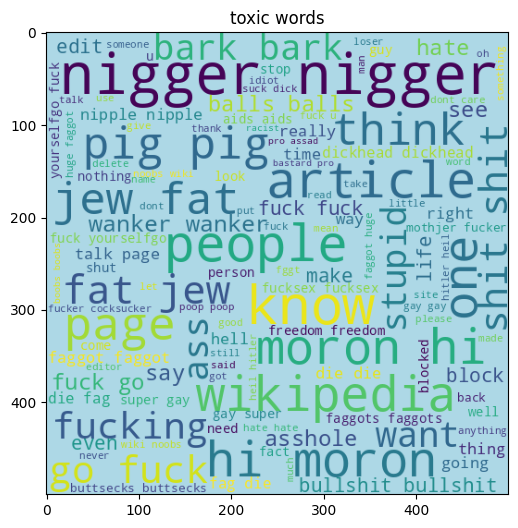

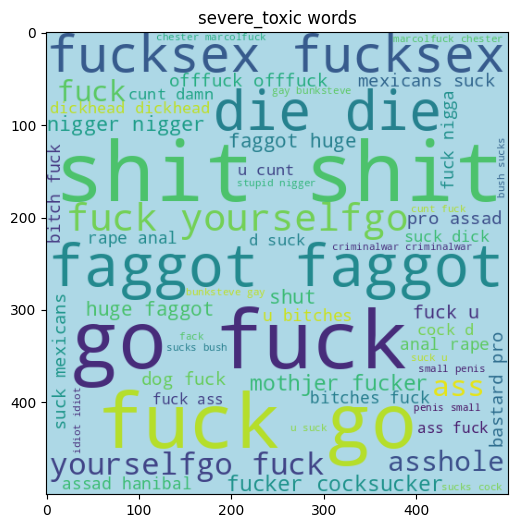

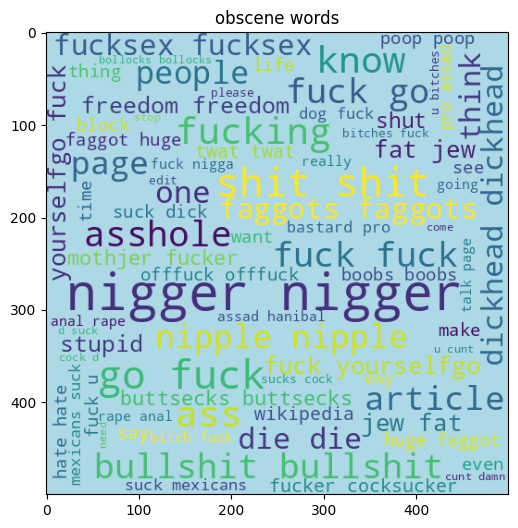

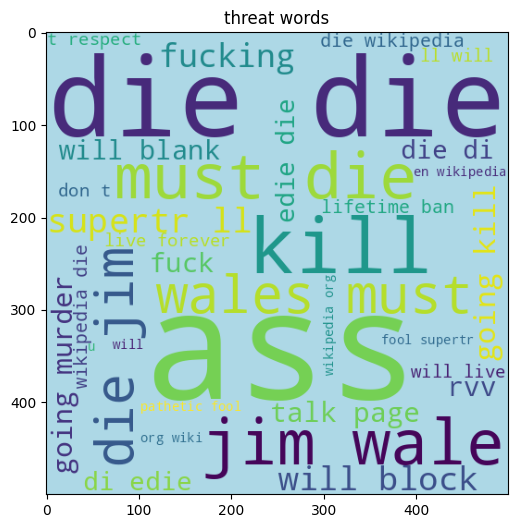

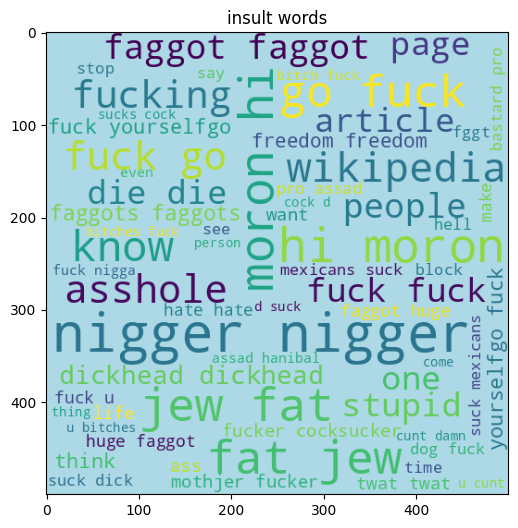

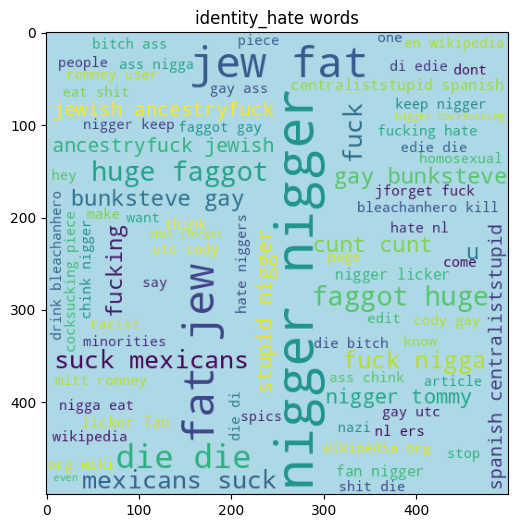

In [118]:
#creating word cloud

from wordcloud import WordCloud
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
for label in labels:
  plt.figure(figsize = (15, 6))

  wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'lightblue')
  wc = wc.generate(train[train[label] == 1]['cleaned_comment_text'].str.cat(sep=" "))
  plt.imshow(wc)
  plt.title(f"{label} words")
  plt.show()